In [3]:
import numpy as np
from dataclasses import dataclass
import random
import matplotlib.pyplot as plt
from matplotlib import animation

In [4]:
@dataclass
class Params:
    N: int #Liczba punktów
    U: int #Zakres w którym generujemu współrzędne punktów
    T: float #Temperatura
    err: float #Poziom błędu przy którym uznajemy temperaturę jako 0
    alfa: float #Wsp. spadku temperatury
    beta: int #Liczba rozpatrywanych zamian na każdym poziomie temperatury

In [6]:
#Parameters
params = Params(100, 100, 70, 1e-2, 0.999, 50)

In [7]:
#Funkcja inicjalizuje w sposób losowy początkową bitmapę.

def initialize_grid(n, density=0.1):
    total_cells = n * n
    num_black = int(total_cells * density)

    #Tworzymy długą listę złożoną z odpowiedniej liczby 0 i 1
    flat_grid = [1] * num_black + [0] * (total_cells - num_black)

    #Mieszamy listę
    random.shuffle(flat_grid)

    #Konwertujemy do odpowiedniej wielkości
    grid = np.array(flat_grid).reshape((n, n))

    return grid

In [8]:
#Funckja oblicza koszt planszy zgodnie z odpowiednią funkcją przyciągania

def get_value(grid, neighbourhood, cost_function):
    n = len(grid)
    cost = 0

    for i in range(n):
        for j in range(n):
            for dx, dy, dist in neighbourhood: #Iterujemuy po sąsiadach
                #Zawijamy modulo n
                if grid[i, j] == grid[(i+dx)%n, (j+dy)%n]:
                    cost -= cost_function(dist)
    #Skoro A sąsiaduje z B to B sąsiaduje z A, zatem liczymy koszt podwójnie

    return cost/2

In [9]:
#Funkcja robi tak jak powyżej, ale bada koszt dla tylko jednej komórki

def get_local_cost(grid, x, y, neighborhood, cost_function):
    n = len(grid)
    local_cost = 0
    for dx, dy, dist in neighborhood:
        if grid[x, y] == grid[(x + dx) % n, (y + dy) % n]:
            local_cost -= cost_function(dist)
    return local_cost

In [29]:
#Algorytm Symulowane Wyżarzania
#Ta wersja jest zoptymalizowana pod kątem obliczania wartości planszy. Za każdym razem nie obliczamy wartości całej planszy lecz ją odpowiednio aktualizujemy obliczając lokalne koszta zamienianych punktów.

def AS(points, T, err, alfa, beta, neighborhood, cost_func):
    n = len(points)
    i = 0

    current_val = get_value(points, neighborhood, cost_func)

    memory = points.copy()
    memory_val = current_val

    outputs = []
    temp = []

    frames = []

    fig, ax = plt.subplots()

    while T > err and i < n * 1000:
        i += 1
        for _ in range(beta):
            #Losujemy współrzędne dwóch punktów do zamiany
            px, py = np.random.randint(0, n, 2)
            qx, qy = np.random.randint(0, n, 2)

            while px == qx and py == qy:
                qx, qy = np.random.randint(0, n, 2)

            #Obliczamy koszt tych punktów w starych pozycjach
            old_cost_p = get_local_cost(points, px, py, neighborhood, cost_func)
            old_cost_q = get_local_cost(points, qx, qy, neighborhood, cost_func)

            #Dokonujemy zamiany punktów
            points[px, py], points[qx, qy] = points[qx, qy], points[px, py]

            #Obliczamy koszt lokalny w nowych pozycjach
            new_cost_p = get_local_cost(points, px, py, neighborhood, cost_func)
            new_cost_q = get_local_cost(points, qx, qy, neighborhood, cost_func)

            #Zmiana energi to różnica pomiędzy nowymi kosztami, a starymi
            delta = (new_cost_p + new_cost_q) - (old_cost_p + old_cost_q)

            accept = False
            if delta < 0: #Korzystna zamiana
                accept = True
            else: #Losujemy dla niekorzystnego przypadku
                p_acc = np.exp(-delta / T)
                if np.random.rand() < p_acc:
                    accept = True

            if accept:
                current_val += delta # w przypadku akceptacji, aktualizujemy koszt o różnicę energi
            else:
                #Powrót do starej pozycji
                points[px, py], points[qx, qy] = points[qx, qy], points[px, py]

            if current_val < memory_val: #Wybiermay najlepszy stan planszy
                memory = points.copy()
                memory_val = current_val

        outputs.append(current_val)

        img = ax.imshow(points.copy(), cmap='binary', animated=True, vmin=0, vmax=1)
        frames.append([img])

        temp.append(T)
        T *= alfa

    return memory, outputs, temp, frames, fig

Sąsiedztwo określa tablica krotek o formule (dx, dy, dist). dx i dy to współrzędne wektora sąsiedztwa, dist określa jego długość.

In [11]:
knight_grid = [
    (2, 2, 1), (-2, -2, 1),
    (2, -2, 1), (-2, 2, 1)
]

morea = [
    (0, 1, 0.1), (0, -1, 0.1),
    (1, 0, 10.0), (-1, 0, 10.0)
]

circle = [
    (0, 1, 1), (0, -1, 1),
    (0, 2, 2), (0, -2, 2)
]

l_shape = [
    (0, 1, 1.0),
    (0, 2, 2.0),
    (1, 0, 1.0)
]

diag =[
    (1, 1, 1),
    (2, 2, 2),
    (-1, -1, 1),
    (-2, -2, 2)
]

double_ring = [
    (0, 1, -1.0), (0, -1, -1.0), (1, 0, -1.0), (-1, 0, -1.0),
    (0, 3, 2.0), (0, -3, 2.0), (3, 0, 2.0), (-3, 0, 2.0)
]

Słownik wszystkich rodzajów sąsiedztw

In [12]:
neighborhoods = {
    "Tetris": l_shape,
    "circle": circle,
    "morea": morea,
    "knight": knight_grid,
    "diag": diag,
    "double_ring": double_ring
}

In [49]:
points = initialize_grid(64, 0.2)

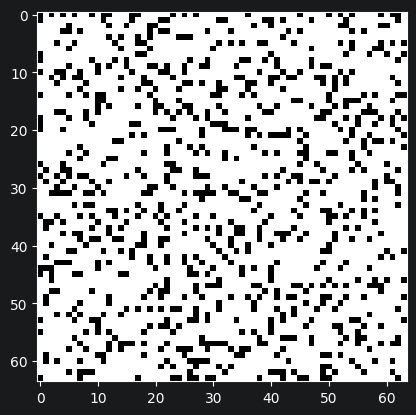

In [50]:
plt.imshow(points, cmap='binary')
plt.show()

Ciekawe funkcje odległości to -1/x, 1/x**2, e^-x^2

In [51]:
 #Funkcje dystansu
reverse = lambda x: -1/x
square = lambda x: 1/x**2
inv = lambda x: 1/x

#Rejestracja nazw sprawia, że łatwo się je zapisuje w pliku
reverse.__name__ = "reverse"
square.__name__ = "square"
inv.__name__ = "inv"

func = [square , inv]

Generowanie obrazów i Gifów
Po wygenrowaniu można zauważyć, że zarówno funkcja odległości jak i sasiedztwa maja znaczenie. Potrafia generowac sie dwa rozne wzory o innej charakterystyce.

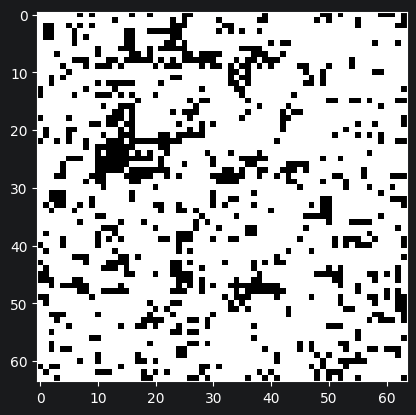

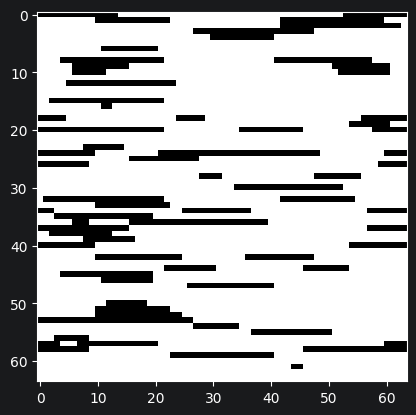

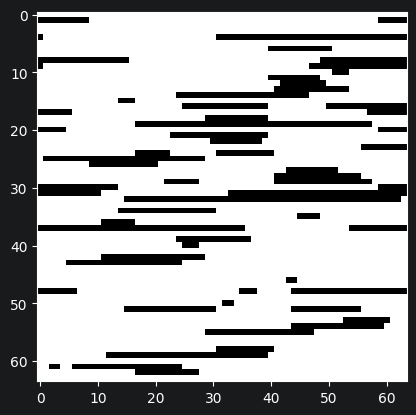

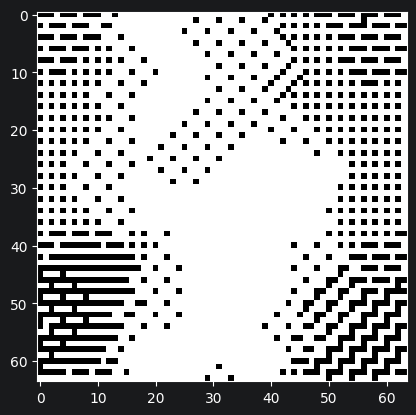

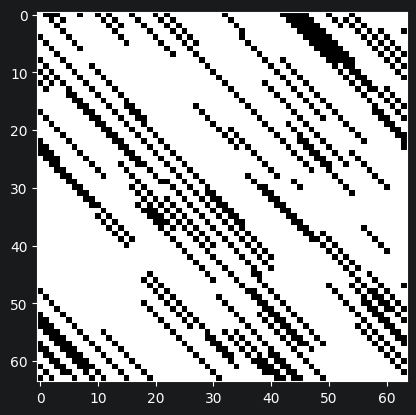

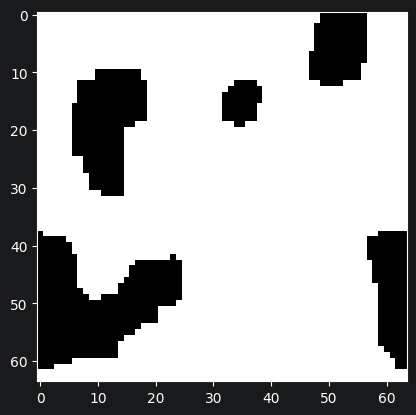

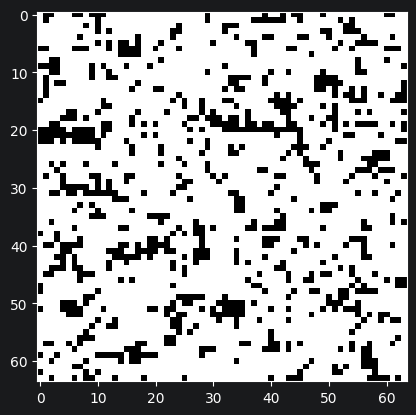

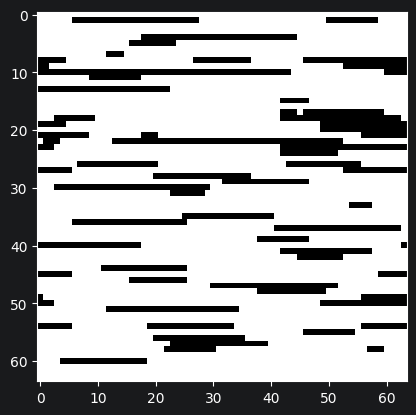

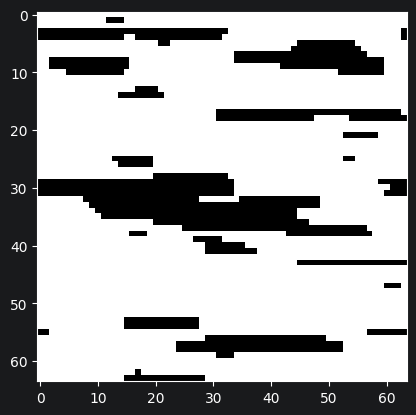

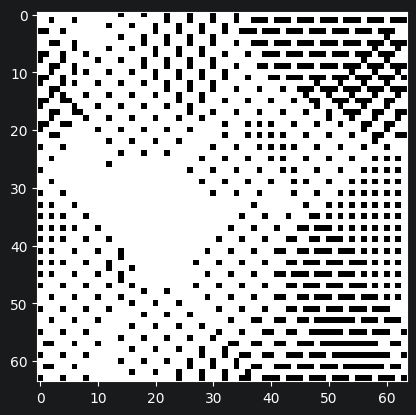

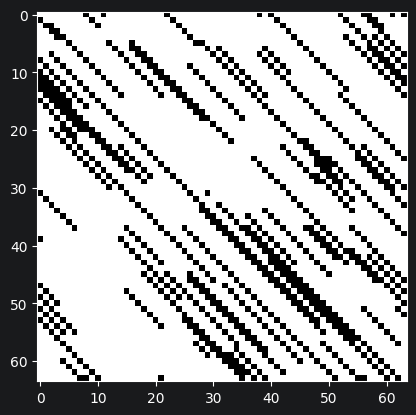

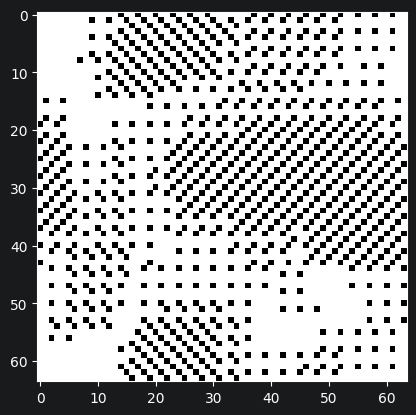

In [53]:
figs_to_save = []
frames_to_save = []
filenames = []

#Parametry zostały dobrane za pomocą prób i błędów
params.alfa = 0.99
params.beta = 2000 #Skoro mam 64*64 pixeli to 2000 zdaje się być odpowiednią wartością
params.T = 1000 #Taka temperatura sprawia, że na początku nasz algorytm wybiera też gorsze stany

for f in func:
    for name, nei_list in neighborhoods.items():
        mem, out_ene, _, frames, my_fig = AS(points, params.T, params.err, params.alfa, params.beta, nei_list, f)

        figs_to_save.append(my_fig)
        frames_to_save.append(frames)
        filenames.append(f"{f.__name__}_{name}")

        my_fig.savefig(f"./img/{f.__name__}_{name}_final.png")

In [54]:
for i in range(len(figs_to_save)):
    print(f"Zapi: {filenames[i]}")

    if not frames_to_save[i]:
        print(f"ERRORRR {filenames[i]}")
        continue

    ani = animation.ArtistAnimation(figs_to_save[i], frames_to_save[i], interval=50, blit=True)

    ani.save(f"./gif/{filenames[i]}.gif", writer='pillow')

    plt.close(figs_to_save[i])

Zapi: square_Tetris
Zapi: square_circle
Zapi: square_morea
Zapi: square_knight
Zapi: square_diag
Zapi: square_double_ring
Zapi: inv_Tetris
Zapi: inv_circle
Zapi: inv_morea
Zapi: inv_knight
Zapi: inv_diag
Zapi: inv_double_ring


Poniżej będą wyświetlone symulacje, bez gifów. Które porównają wpływ spadku temperatury, gęstości.

Tak jak można zaobserwować, zmiana szybkości spadku temperatury ma ogromne znaczenie. Gdy temperatura spada zbyt szybko, kończymy symulację w gorszym stanie energetycznym. W efekcie czego skośne linie są słabiej uformowane

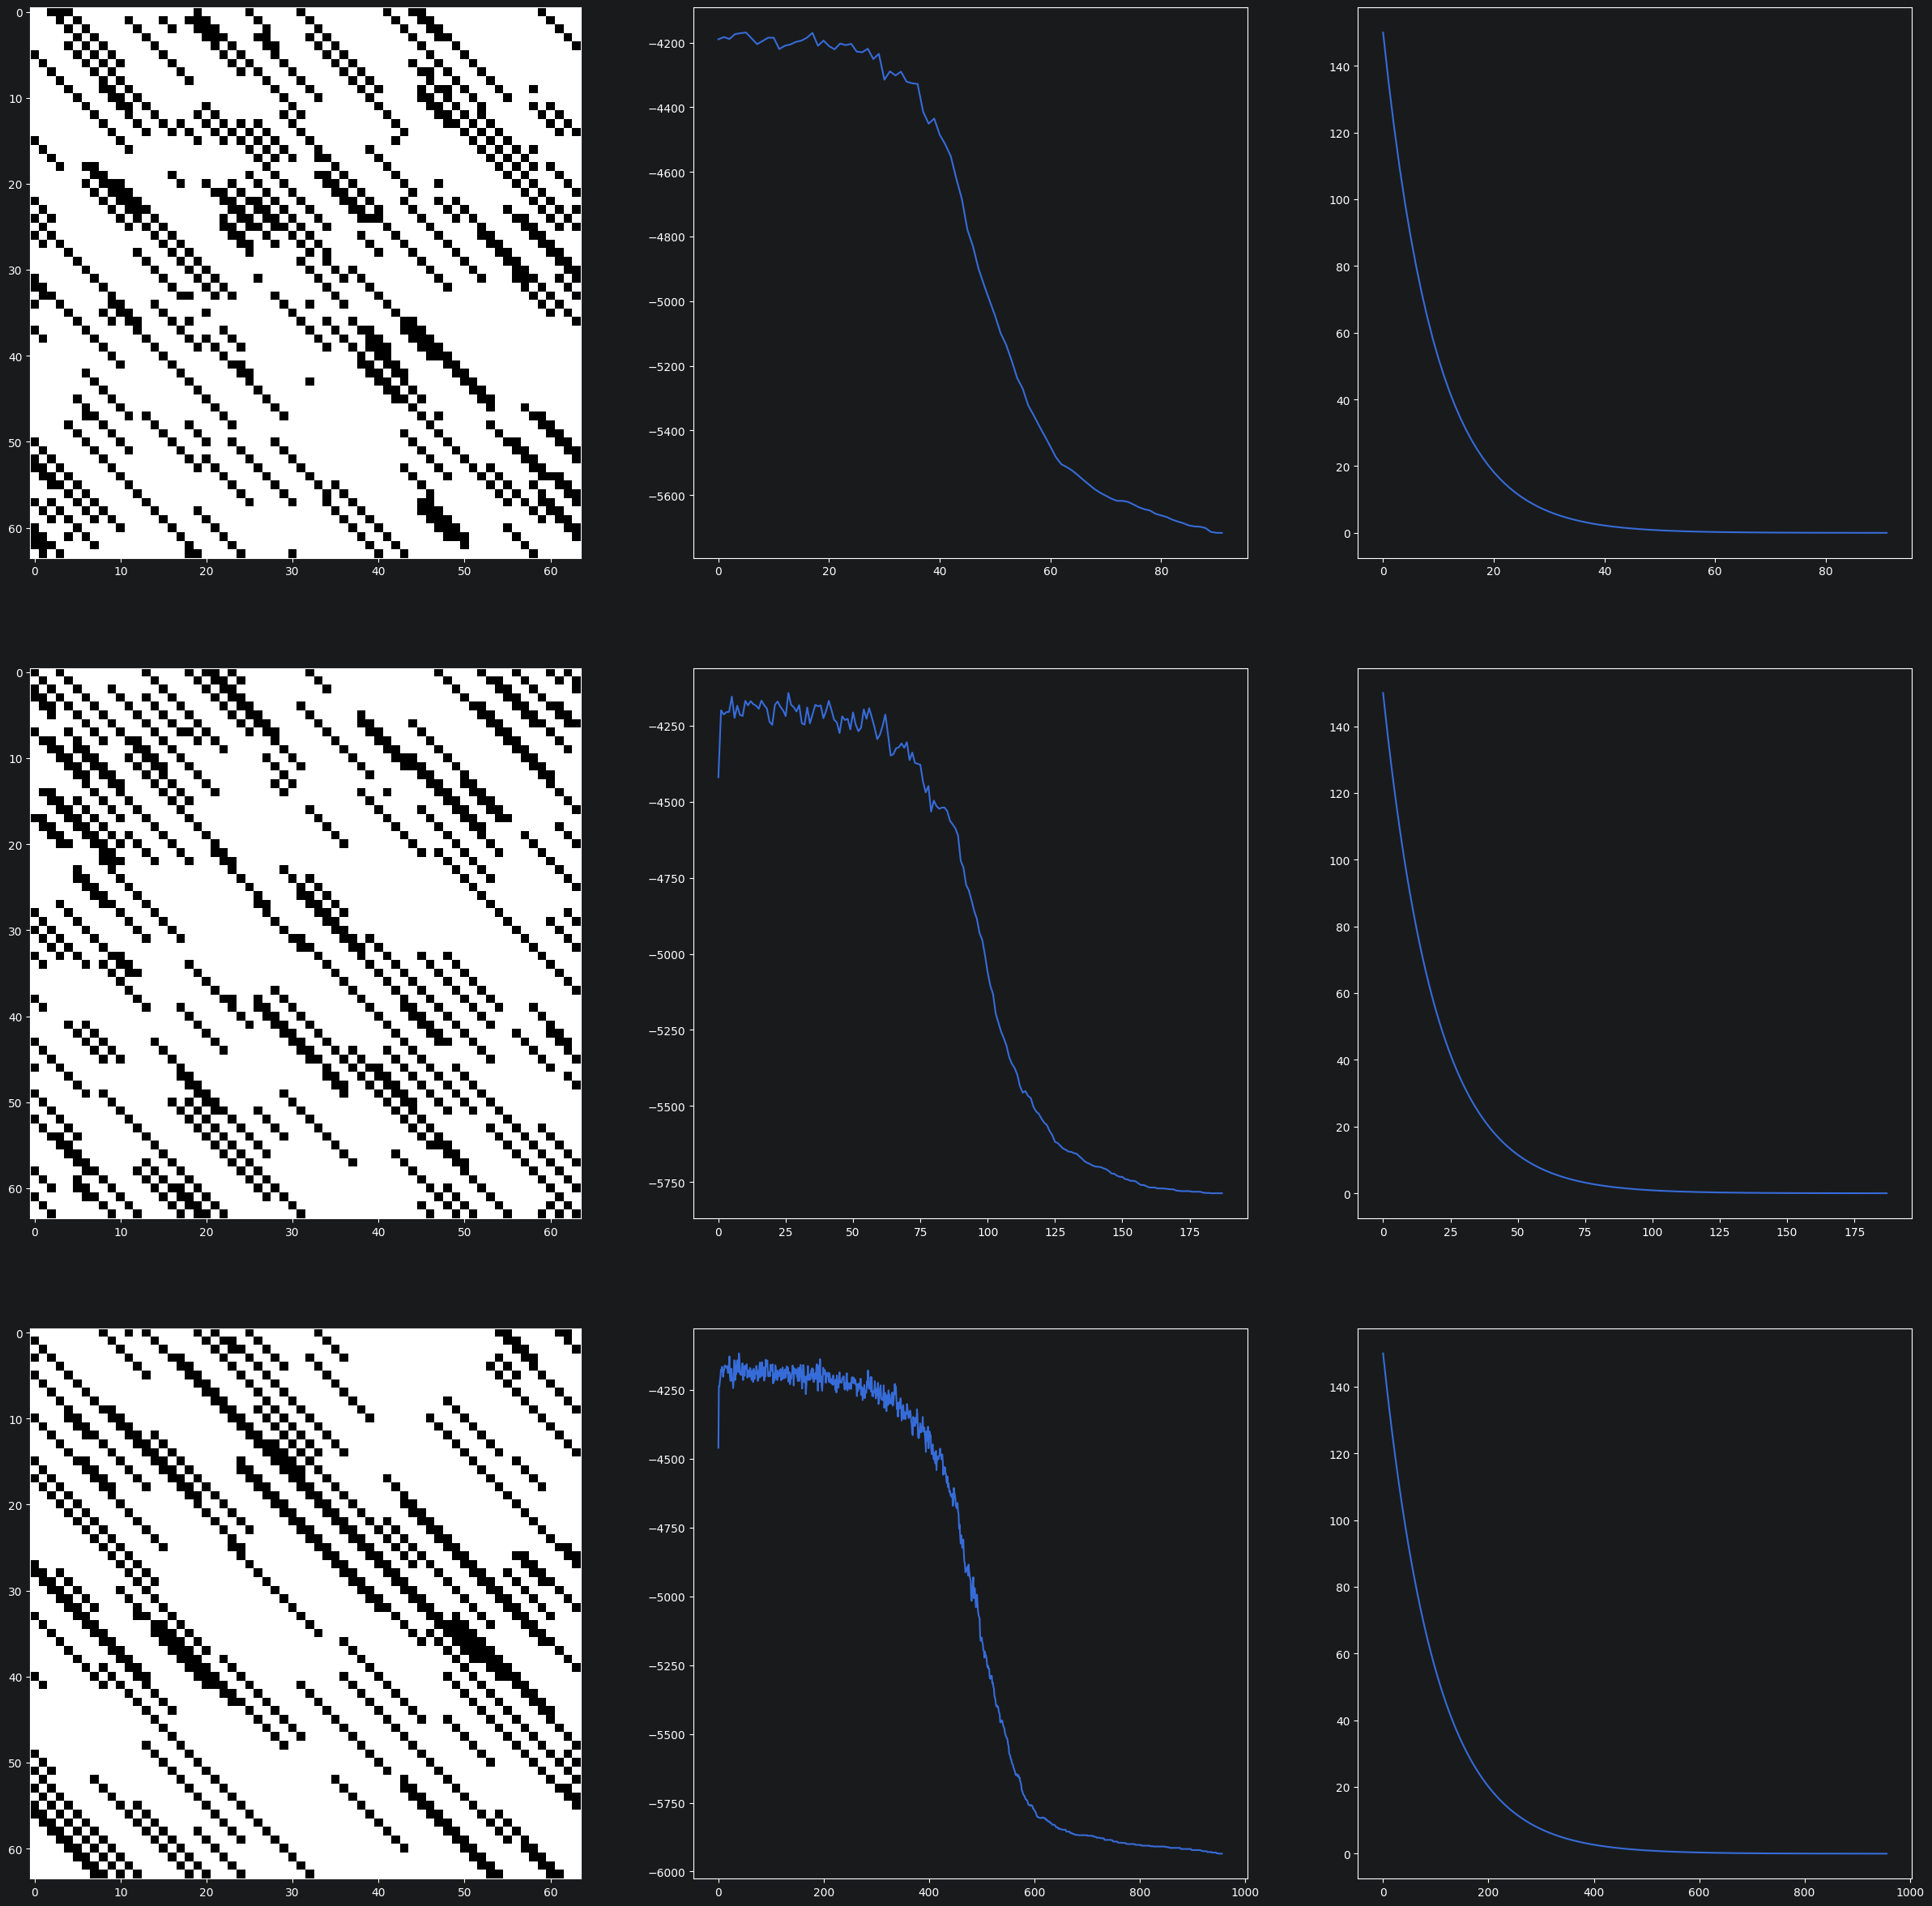

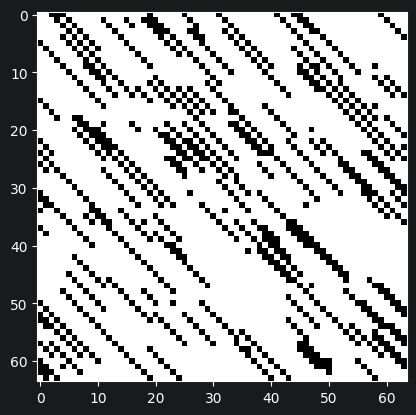

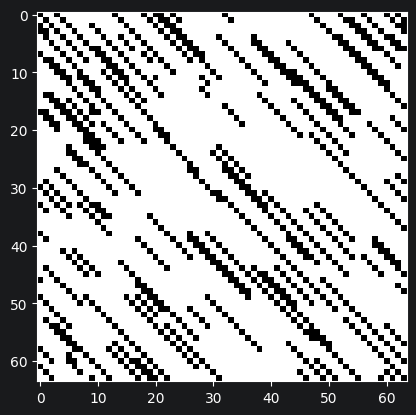

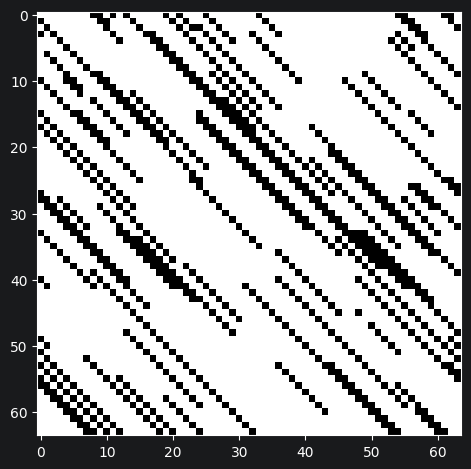

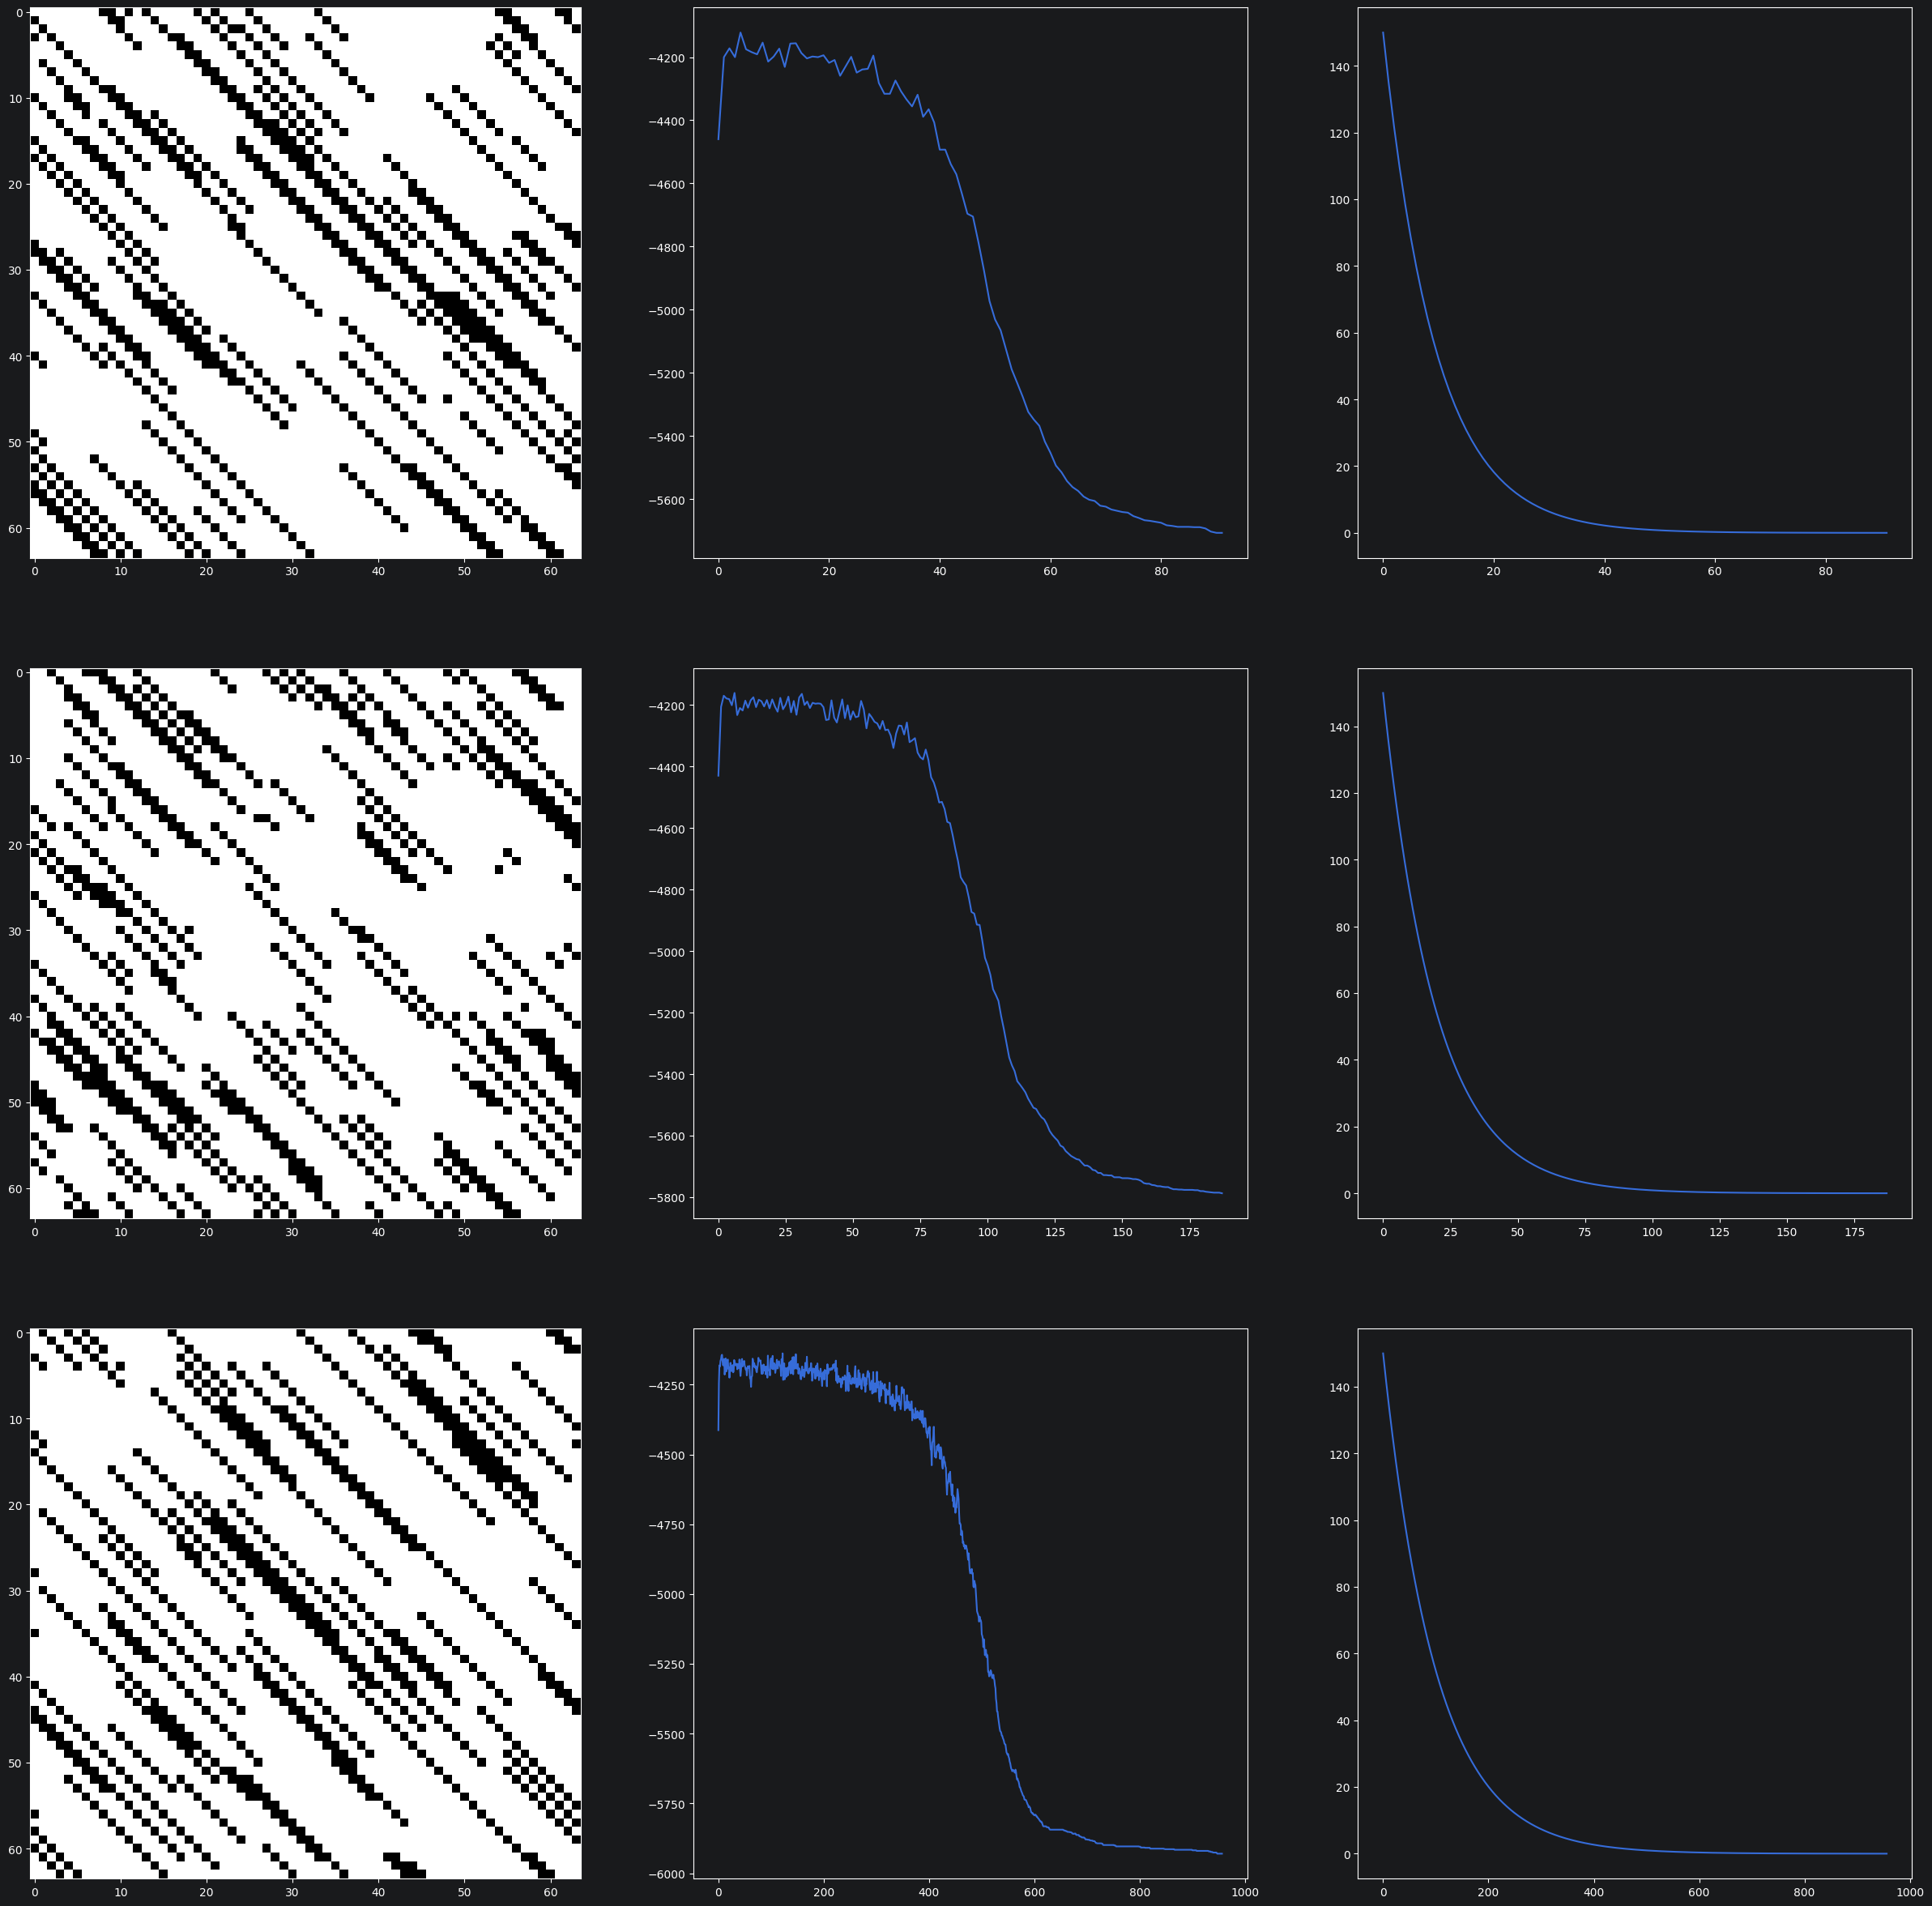

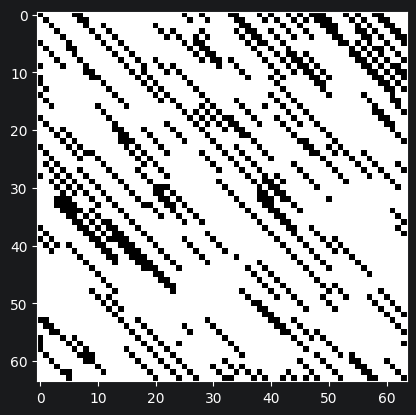

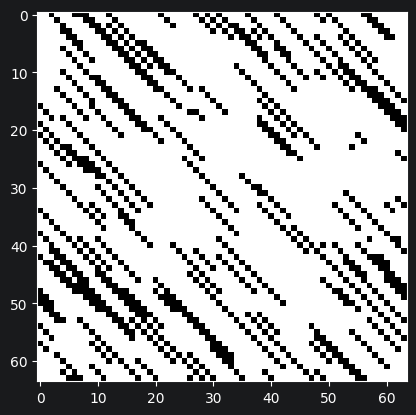

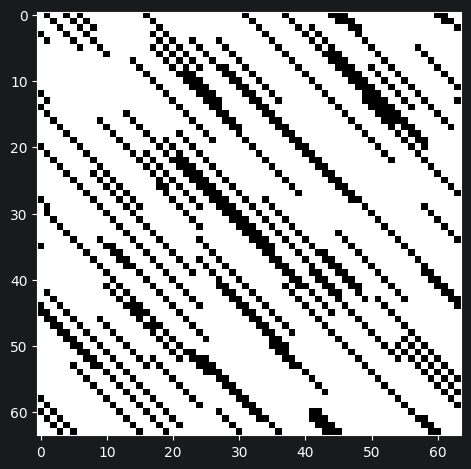

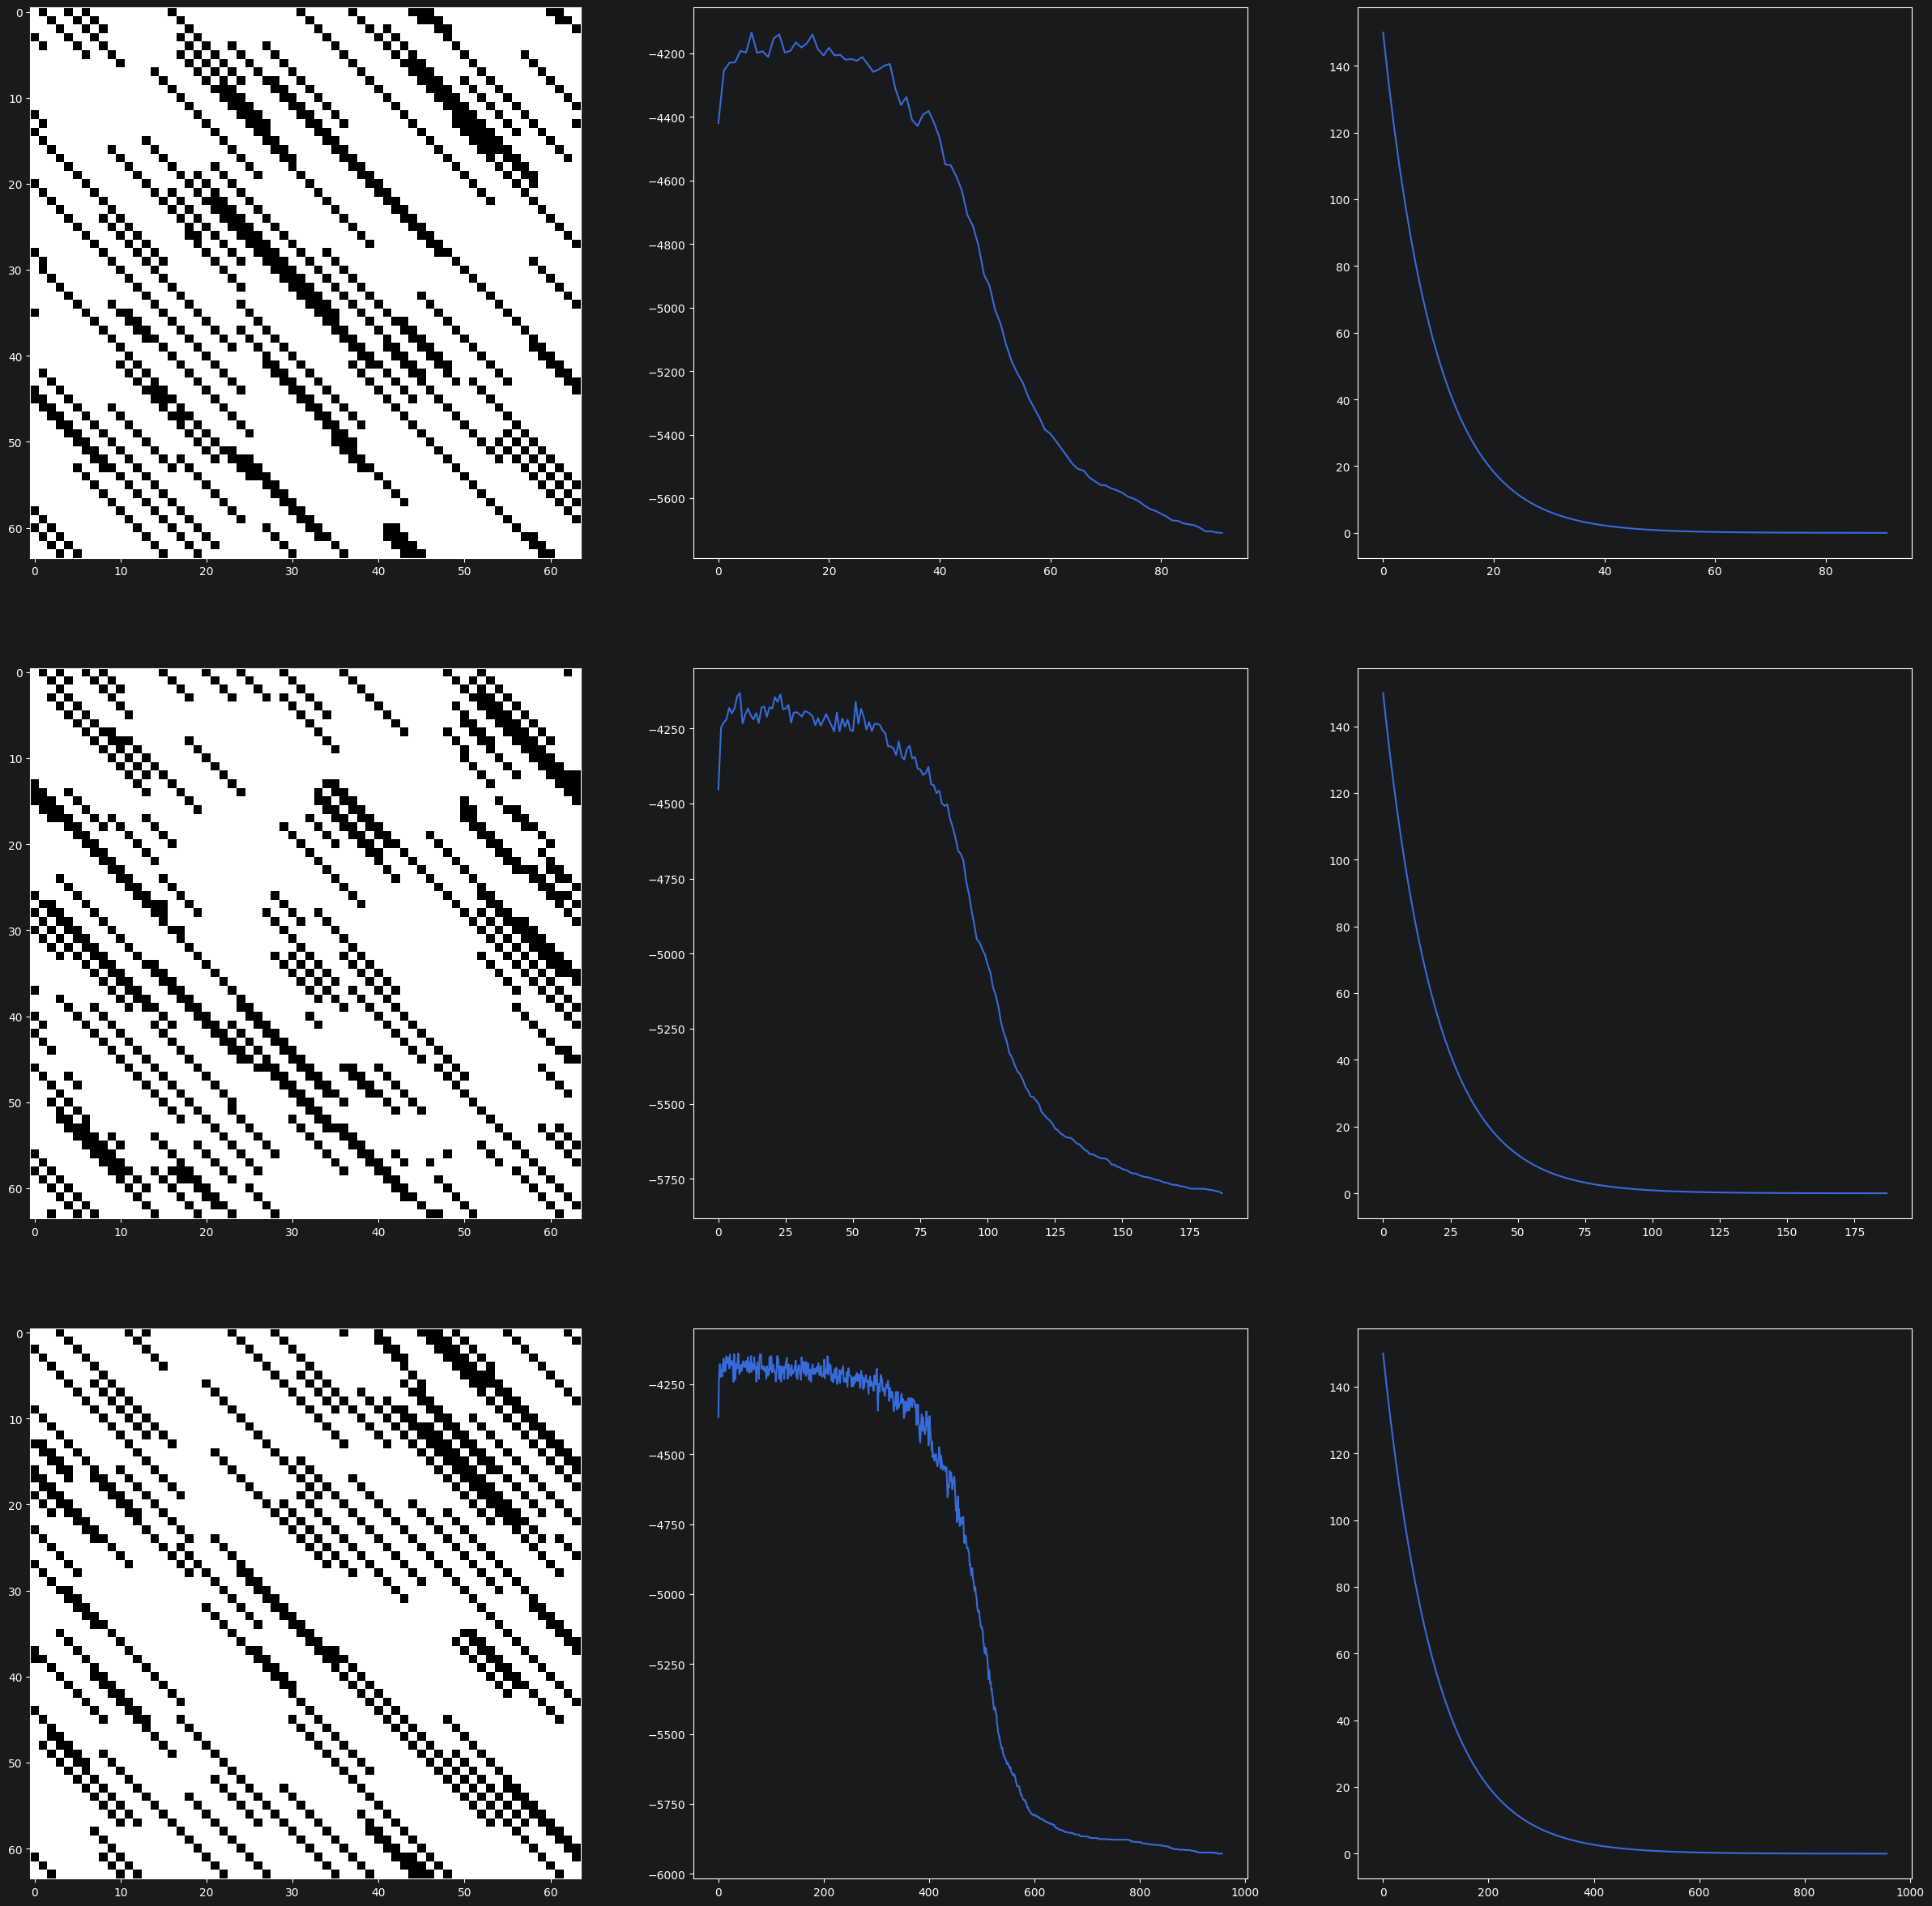

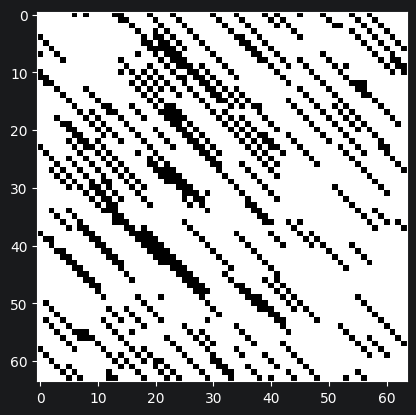

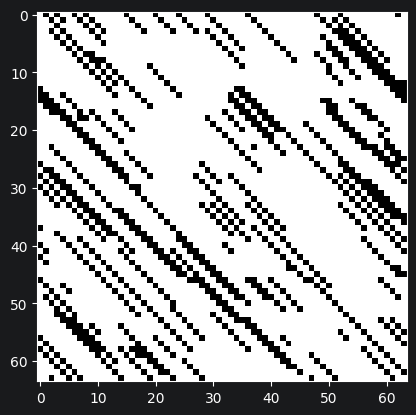

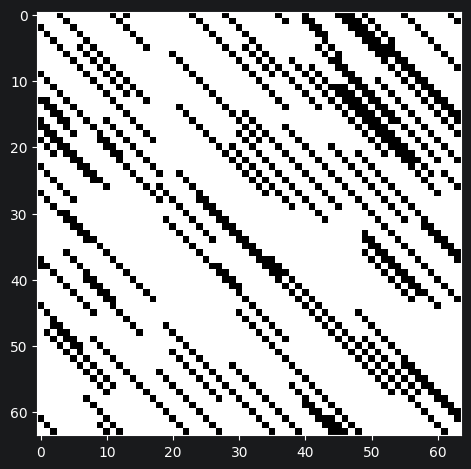

In [57]:
density = [0.1, 0.2, 0.3]
temp = [0.90, 0.95, 0.99]

params.T = 150
params.beta = 2000

for ro in density:
    grid = initialize_grid(256, ro)
    fig, ax = plt.subplots(3, 3, figsize=(30, 30))
    for i, t in enumerate(temp):
        params.alfa = t
        mem, out, temp_out, frames, my_fig = AS(points, params.T, params.err, params.alfa, params.beta, diag, inv)

        ax[i, 0].imshow(mem, cmap='binary')
        ax[i, 1].plot(out)
        ax[i, 2].plot(temp_out)

    plt.tight_layout()
    plt.show()
